In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
#%reset

Nothing done.


In [2]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time
import pycountry
import geopandas as gpd
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap, Normalize, ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import textwrap
import fiona

from src.text_processing_functions import *
from src.LLM_functions import *
from src.data import *
from src.post_process_functions import *
from src.geocoding import *
from src.hazard_def import *
from src.impact_def import *
from src.ImpactRegistry import Impacts
from src.impact_def import IMPACT_SUBTYPE_MERGER, IMPACT_SUBTYPES_MERGED

path_save_fig = DATA_FIGURE / "data_overview"
#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# 200 reports 
# res_name_llm = "post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
# res_name_llm = "post_processed_all_appeals_unique_1-333_meta-llama_llama-4-scout-17b-16e-instruct_v281025"
# res_name_llm = "post_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v171225"
res_name_llm = "merged_subtypes_post_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v171225"
# df_llm_all = pd.read_csv(os.path.join(DATA_OUT_PROC, res_name_llm+'.gpkg'), encoding='utf-8')
# df_llm_all_geo = gpd.read_file(os.path.join(DATA_OUT_PROC, res_name_llm+'.gpkg'), engine="fiona")
df_llm_all_geo = pd.read_parquet(DATA_OUT_PROC / (res_name_llm+'.parquet'))

# col_to_list = ["location", "country", "country_kw", "country_iso3", "hazards"]
# df_llm_all[col_to_list] = df_llm_all[col_to_list].map(lambda x: listify_strings(x))

col_to_list = ["location", "country", "country_kw", "country_iso3", "locationOsm", "locationPolygon", "iso3_code", "hazards"]
df_llm_all_geo[col_to_list] = df_llm_all_geo[col_to_list].map(lambda x: listify_strings(x))

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\lhasbini\\ownCloud\\Documents\\Thèse\\Conférences_Discussions\\2024_Como_Compound Events Training\\data\\results_proc\\post_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v171225.parquet'

In [5]:
# Import 
world = gpd.read_file(ADMIN_PATH / "ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp")
# admin1 = gpd.read_file(DATA_PATH_ADMIN+"ne_10m_admin_1_states_provinces/"+'ne_10m_admin_1_states_provinces.shp')
# rivers = gpd.read_file(DATA_PATH_ADMIN+"ne_10m_rivers_lake_centerlines/"+'ne_10m_rivers_lake_centerlines.shp')
# cities = gpd.read_file(DATA_PATH_ADMIN+"ne_10m_populated_places/"+'ne_10m_populated_places.shp')

In [6]:
def get_continent(iso_code, world):
    try:
        return world[world['ISO_A3'] == iso_code]['CONTINENT'].values[0]
    except IndexError:
        return None

In [7]:
continent_offsets = {
    'Africa': (0, -0.20),
    'Asia': (0.15, -0.05),
    'Europe': (-0.15, -0.02),
    'Oceania' : (0.08, 0.02),
    'North America' : (-0.05, -0.15),
    'South America' : (-0.05, -0.02)
}

# Hazard Map

In [24]:
hazard_colormap = {
    # 🔥 Environmental & Climatic
    'Drought': '#C2B280',                # sandy beige — dry/arid land
    'Wildfire': '#D1495B',               # strong red — fire and danger
    'Extreme warm temperature': '#E26D5A',# coral/orange — heat
    'Extreme cold temperature': '#A6CEE3',# icy blue — cold

    # 🌋 Geophysical
    'Earthquake': '#7F7F7F',             # neutral gray — ground rupture
    'Mass movement': '#8C564B',          # earthy brown — landslides
    'Volcanic activity': '#E17C05',      # lava orange — volcanic tones

    # 🌊 Hydrological / Meteorological
    'Flood': '#1F77B4',                  # deep blue — water/flood
    'Wave action': '#17BECF',            # cyan — ocean/wave
    'Tropical storm': '#2CA02C',         # green — tropical vegetation/storm
    'Convective storm': '#5B8E7D',       # teal — thunderstorm tone
    'Other storm': '#BCBD22',            # olive — extratropical/windstorm

    # ☣️ Biological / Social
    'Epidemic': '#E377C2',               # magenta — biological hazard
    'Conflict': '#7F3121'                # dark red-brown — violence/unrest
}

hazard_order = list(hazard_colormap.keys())

In [17]:
all_reports_grp = df_llm_all_geo.explode('iso3_code').groupby('appealCode').agg(iso_code = ("iso3_code", "first")).reset_index()

In [18]:
all_reports_country_count = all_reports_grp.groupby("iso_code").agg(appeal_count = ("appealCode", "nunique"))

In [19]:
# df = pd.DataFrame(list(country_appeal_count.items()), columns=["iso_code", "appeal_count"])
world_2 = world.merge(all_reports_country_count, how="left", left_on="ISO_A3", right_on="iso_code")

In [20]:
df_llm_all_geo['continent'] = df_llm_all_geo['iso3_code'].apply(
    lambda iso_list: list({get_continent(iso, world_2) for iso in iso_list if iso}) 
    if isinstance(iso_list, list) else None
)

# Filter out rows without continent
valid_continents = df_llm_all_geo.dropna(subset=['continent'])
df = valid_continents.explode('continent').explode('hazards')
df = df.dropna(subset=['continent', 'hazards'])
df_unique = df.drop_duplicates(subset=['appealCode', 'continent', 'hazards'])

# Group and count number of unique appeals per continent and hazard
hazard_counts = (
    df_unique
    .groupby(['continent', 'hazards'])['appealCode']
    .nunique()   # count unique appeal codes
    .unstack(fill_value=0)
)

In [28]:
hazard_counts.loc[continent_order]

hazards,Drought,Wildfire,Extreme warm temperature,Extreme cold temperature,Earthquake,Mass movement,Volcanic activity,Flood,Wave action,Tropical storm,Convective storm,Other storm,Epidemic,Conflict
continent,,,,,,,,,,,,,,
North America,16,9,11,8,15,38,7,120,7,57,99,35,25,4
South America,12,5,5,7,8,36,6,100,1,33,71,18,28,2
Europe,3,4,5,4,4,12,1,30,0,0,24,6,9,1
Africa,40,12,15,15,10,48,6,253,6,53,168,39,84,14
Asia,33,7,17,25,39,68,10,197,11,72,139,59,65,16
Oceania,7,1,1,4,5,11,7,37,4,15,26,7,15,1


C:\Users\lhasbini\AppData\Local\Temp\ipykernel_21488\4184518070.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=30, ha='right')


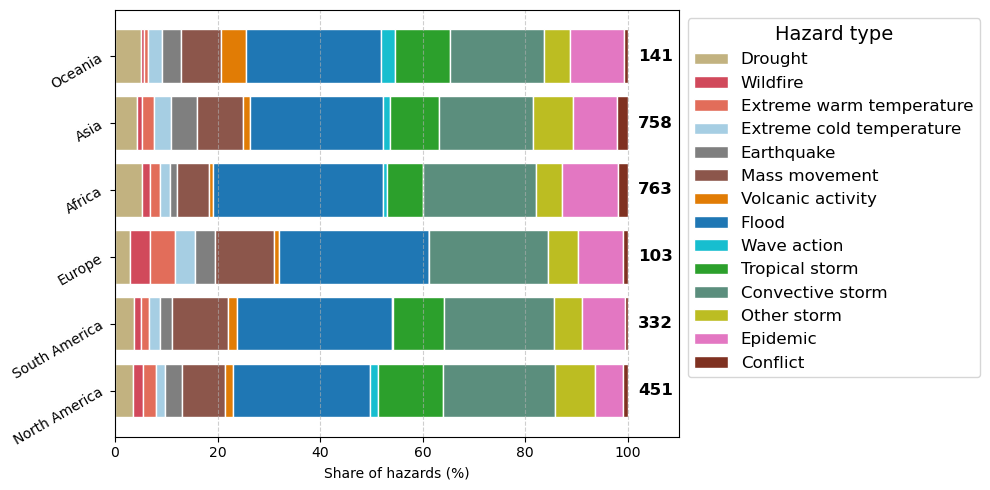

In [29]:
continent_order = ['North America', 'South America', 'Europe', 'Africa', 'Asia',  'Oceania']

# Ensure the columns follow the order of hazard_colormap
# hazard_order = [h for h in hazard_colormap.keys() if h in hazard_counts.columns]
hazard_counts = hazard_counts.loc[continent_order]
hazard_counts = hazard_counts[hazard_order]

# Convert to percentage per continent
hazard_counts_percent = hazard_counts.div(hazard_counts.sum(axis=1), axis=0) * 100
hazard_counts_total = hazard_counts.sum(axis=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

left = [0] * len(hazard_counts)
for hazard in hazard_counts.columns:
    ax.barh(
        hazard_counts.index,
        hazard_counts_percent[hazard],
        left=left,
        color=hazard_colormap.get(hazard, 'gray'),
        edgecolor='white',
        label=hazard
    )
    left += hazard_counts_percent[hazard].values

# Add total counts at end of each bar
for i, total in enumerate(hazard_counts_total):
    ax.text(102, i, f'{total}', va='center', fontsize=12, fontweight='bold')

# Formatting
ax.set_xlim(0, 110)
ax.set_xlabel('Share of hazards (%)')
ax.set_ylabel('')
# ax.set_title('Distribution of Hazard Types by Continent', fontweight='bold')

# Add vertical gridlines from x-axis
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.grid(False)

# Rotate y-axis labels slightly
ax.set_yticklabels(ax.get_yticklabels(), rotation=30, ha='right')

# Legend
ax.legend(bbox_to_anchor=(1, 1), loc='upper left', title='Hazard type', title_fontsize=14, fontsize=12)

# Save fig
fig.savefig(path_save_fig / f"hazard_share_continents.png", 
            transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"hazard_share_continents.svg", 
            format="svg", transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"hazard_share_continents.pdf", 
            format="pdf", transparent=True, bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

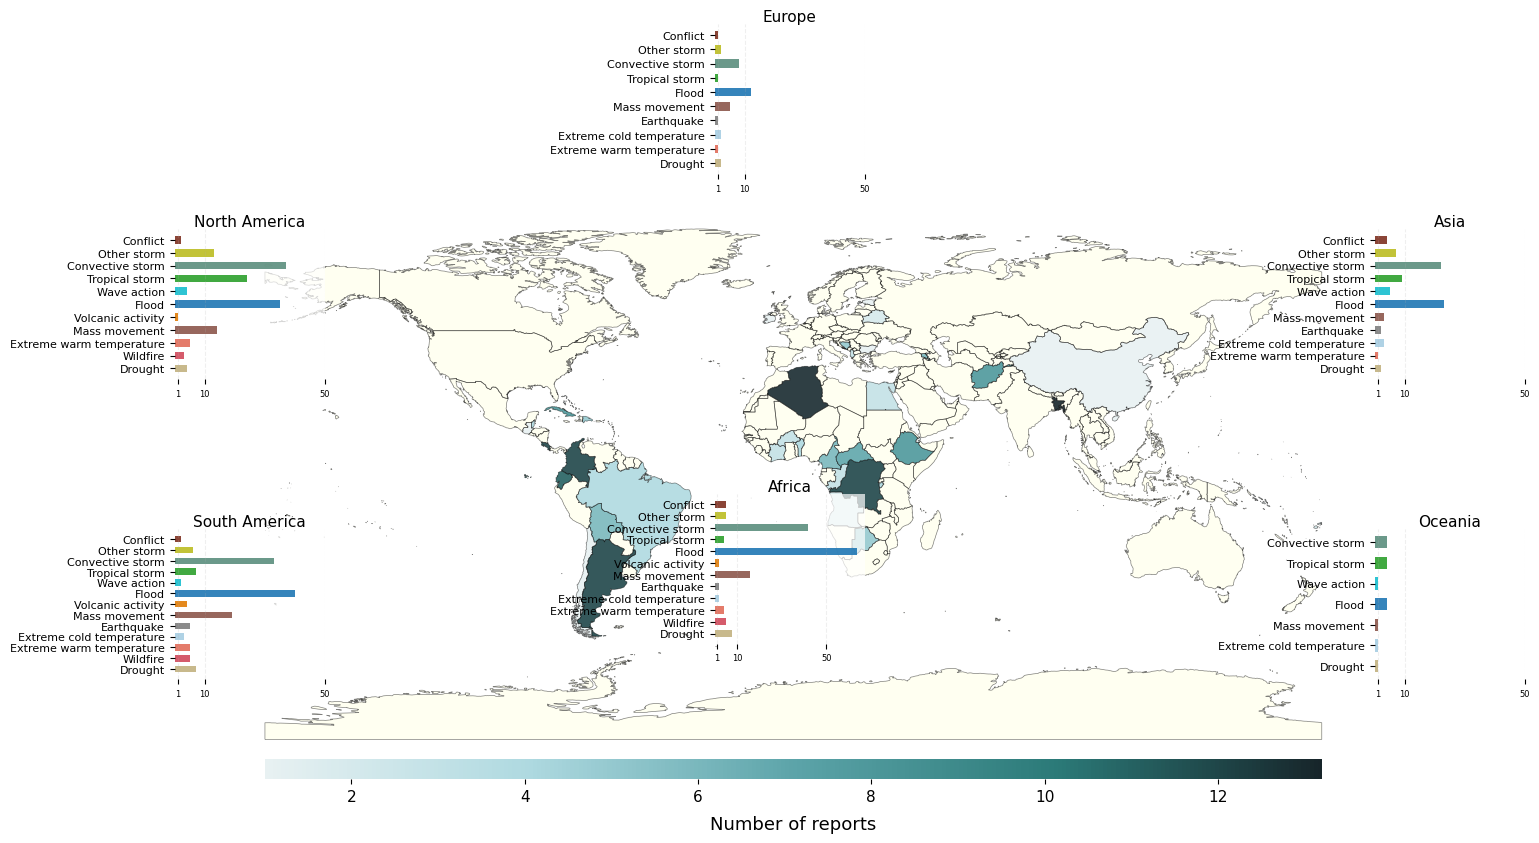

In [66]:
# Step 3: Plot the static choropleth map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Transparent country boundaries
world_2.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.5)  # Semi-transparent boundaries
# sequential_cmap = LinearSegmentedColormap.from_list(
#     "neutral_blue_sequential",
#     ["#E0FBFC", "#5C8EAD", "#2A9D8F", "#264653"],
#     N=256
# )
# world_plot = world_2.plot(column="appeal_count",
#                         ax=ax,
#                         legend=False,
#                         cmap=sequential_cmap,
#                         missing_kwds={
#                             "color": "ivory",
#                             "label": "No data"
#                         }, alpha=0.5)

# # Reduce the size of the colorbar
# sm = plt.cm.ScalarMappable(cmap=sequential_cmap, norm=plt.Normalize(vmin=world_2['appeal_count'].min(), vmax=world_2['appeal_count'].max()))
# sm._A = []  # Dummy array for ScalarMappable
# cbar_ax = fig.add_axes([0.16, 0.2, 0.705, 0.02])  # [left, bottom, width, height]
# cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
# cbar.ax.tick_params(labelsize=12)
# cbar.set_label("Number of reports", fontsize=14)

sequential_cmap = LinearSegmentedColormap.from_list(
    "blue_teal_seq",
    ["#E8F1F2", "#AED9E0", "#5CA4A9", "#2B7A78", "#17252A"],  # light → dark
    N=256
)

# Normalize appeal_count to emphasize variation (especially if skewed)
norm = Normalize(
    vmin=world_2["appeal_count"].quantile(0.02),  # ignore extreme low outliers
    vmax=world_2["appeal_count"].quantile(0.98)   # ignore extreme highs
)

# --- Choropleth plot ---
world_plot = world_2.plot(
    column="appeal_count",
    ax=ax,
    legend=False,
    cmap=sequential_cmap,
    norm=norm,
    missing_kwds={
        "color": "ivory",
        "label": "No data"
    },
    alpha=0.9
)

# --- Adjusted colorbar (smaller, cleaner, readable) ---
sm = cm.ScalarMappable(cmap=sequential_cmap, norm=norm)
sm._A = []  # Dummy array for colorbar creation

cbar_ax = fig.add_axes([0.16, 0.2, 0.705, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")

# --- Labels & style ---
cbar.ax.tick_params(labelsize=11)
cbar.outline.set_visible(False)
cbar.set_label("Number of reports", fontsize=13, labelpad=8)

######## ADD HAZARD INFORMATION 
ax.set_axis_off()

df_llm_all_geo['continent'] = df_llm_all_geo['iso3_code'].apply(
    lambda iso_list: list({get_continent(iso) for iso in iso_list if iso}) 
    if isinstance(iso_list, list) else None
)

# Filter out rows without continent
valid_continents = df_llm_all_geo.dropna(subset=['continent'])

# Group by continent and hazard type
df = valid_continents.explode('continent').explode('hazards')

# Drop rows with missing values (optional)
df = df.dropna(subset=['continent', 'hazards'])

# Drop duplicates to count each appeal only once per continent/hazard
df_unique = df.drop_duplicates(subset=['appealCode', 'continent', 'hazards'])

# Group and count number of unique appeals per continent and hazard
hazard_counts = (
    df_unique
    .groupby(['continent', 'hazards'])['appealCode']
    .nunique()   # count unique appeal codes
    .unstack(fill_value=0)
)

# Make the plot
# Reprojected centroids and figure assumed defined:
# fig, world_2, continent_centroids, hazard_counts

continent_shapes = world_2.dissolve(by='CONTINENT')#.to_crs('ESRI:54030')
# continent_centroids = continent_shapes.geometry.centroid
continent_shapes_proj = continent_shapes.to_crs("ESRI:54030")
continent_centroids_proj = continent_shapes_proj.centroid

# Reproject centroids back to original CRS (WGS84) to overlay on the map
continent_centroids = continent_centroids_proj.to_crs(world_2.crs)

continents_plot = ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']

for continent in continents_plot:
    if continent not in continent_centroids.index or continent not in hazard_counts.index:
        continue

    centroid = continent_centroids.loc[continent]
    if pd.isna(centroid.x) or pd.isna(centroid.y):
        continue

    try:
        # Determine subplot position offsets
        x_offset, y_offset = continent_offsets.get(continent, (0, 0))
        if continent in ['North America', 'South America']:
            x_value = 0.1
        elif continent in ['Asia', 'Oceania']:
            x_value = 0.9
        else:
            x_value = 0.46

        if continent in ['North America', 'Asia']:
            y_value = 0.6
        elif continent in ['South America', 'Oceania']:
            y_value = 0.3
        else:
            y_value = (centroid.y + 90) / 180 + y_offset  # approximate normalization

        # Create a small axis for the bar plot
        ax_bar = fig.add_axes([x_value, y_value, 0.1, 0.15])
        ax_bar.set_facecolor('white')
        ax_bar.patch.set_alpha(0.7)

        # Get hazard data for the continent
        data = hazard_counts.loc[continent]
        data = data[data > 0]  # keep only nonzero categories
        if data.empty:
            continue
        data = data.reindex(hazard_order)
        data = data.dropna()

        # Prepare data
        hazards = data.index
        values = data.values

        # Assign colors with fallback to gray if missing in dict
        colors = [dict_color.get(h, '#BBBBBB') for h in hazards]

        # Plot horizontal bars
        ax_bar.barh(
            y=np.arange(len(values)),
            width=values,
            color=colors,
            alpha=0.9,
            height=0.6
        )

        # Titles and labels
        ax_bar.set_title(continent, fontsize=11, pad=2)
        ax_bar.title.set_position([0.5, 1.1])
        ax_bar.set_yticks(range(len(hazards)))
        ax_bar.set_yticklabels(hazards, fontsize=8)
        # ax_bar.set_xscale('log')
        ax_bar.set_xticks([1, 10, 50])
        ax_bar.tick_params(axis='x', labelsize=6)
        for spine in ax_bar.spines.values():
            spine.set_visible(False)
        ax_bar.grid(axis='x', alpha=0.2, linestyle='--')

    except Exception as e:
        print(f"⚠️ Error plotting {continent}: {e}")
        continue


# Impact Map

In [ ]:
impact_colormap = {
    'Human': '#B23A2E',                             # Red — human impacts
    'Infrastructure and Service access': '#5C7A6E', # Blue — buildings, roads, utilities
    # 'Service access': '#BC80BD',                    # Purple — access to services
    # 'Agriculture': '#7FBF7F',                       # Greenish — crops, livestock
    'Economic Activity and Livelihood Production': '#B97F3B',  # Orange — economy/business
}

In [46]:
def merge_impact_subtypes(df, column="impactSubtype"):
    df = df.copy()

    for merged_name, pattern in IMPACT_SUBTYPE_MERGER.items():
        mask = df[column].str.contains(pattern, regex=True, na=False)
        df.loc[mask, column] = merged_name

    return df

In [47]:
df_llm_all_geo["impactSubtype"].unique()

array(['Affected People', 'Homeless People', 'Human Deaths',
       'Targeted People', 'Assisted People', 'Residential Buildings',
       'Agriculture and Access to Food', 'Healthcare',
       'Human Health and Wellbeing', 'Economy and Livelihood',
       'Water, Sanitation, and Hygiene', 'Education', 'Displaced People',
       'Missing People', 'Infected and Ill People', 'Transportation',
       'IT and Communication', 'Informal Settlements',
       'Power and Energy Production', 'Recreation, Tourism, and Culture',
       'Undefined Infrastructure and Service Access', 'Injured People',
       'DREF Allocation', 'Unknown'], dtype=object)

In [48]:
len(df_llm_all_geo.loc[df_llm_all_geo['impact_main_type'].isna()])

986

In [49]:
# Step 0: Get mapping dict from subtype → main type
# impact_subtype_to_main = Impacts.get_main_types()  # Already a dict

# Step 1: Map each impactSubtype in your DataFrame
df_llm_all_geo = merge_impact_subtypes(df_llm_all_geo, column="impactSubtype")
df_llm_all_geo['impact_main_type'] = df_llm_all_geo['impactSubtype'].map(IMPACT_TYPES_MERGED)

# Optional: check for unmapped subtypes
unmapped = df_llm_all_geo.loc[df_llm_all_geo['impact_main_type'].isna(), 'impactSubtype'].unique()
if len(unmapped) > 0:
    print("⚠️ Unmapped impact subtypes:", unmapped)

# --- Step 2: Now you can safely count per appeal ---
all_report_count = (
    df_llm_all_geo
    .explode('iso3_code')
    .groupby(['appealCode', "impact_main_type"])
    .agg(
        impact_number=("impactSubtype", "count"),   # total number of impact entries
        iso_code=("iso3_code", "first")
    )
    .reset_index()
)

⚠️ Unmapped impact subtypes: ['Unknown']


C:\Users\lhasbini\AppData\Local\Temp\ipykernel_19568\1999123951.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df[column].str.contains(pattern, regex=True, na=False)
C:\Users\lhasbini\AppData\Local\Temp\ipykernel_19568\1999123951.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df[column].str.contains(pattern, regex=True, na=False)
C:\Users\lhasbini\AppData\Local\Temp\ipykernel_19568\1999123951.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df[column].str.contains(pattern, regex=True, na=False)
C:\Users\lhasbini\AppData\Local\Temp\ipykernel_19568\1999123951.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extra

In [50]:
# all_report_impact_count = all_report_count.groupby(["iso_code", "impact_main_type"]).agg(impact_count = ("impact_number", "sum")).reset_index()
all_report_impact_count = all_report_count.groupby(["iso_code"]).agg(impact_count = ("impact_number", "sum")).reset_index()
all_report_impact_maintype_count = all_report_count.groupby(["iso_code", "impact_main_type"]).agg(impact_count = ("impact_number", "sum")).reset_index()

In [51]:
all_reports_impactsubtype = df_llm_all_geo.groupby(["impactSubtype"]).agg(impact_subtype_count = ("country", "count"), impact_main_type = ("impact_main_type", "first")).reset_index()
all_reports_impactsubtype['color'] = all_reports_impactsubtype['impact_main_type'].map(impact_colormap)
all_reports_impactsubtype = all_reports_impactsubtype.dropna(subset=["color"])
all_reports_impactsubtype = all_reports_impactsubtype.set_index('impactSubtype')
all_reports_impactsubtype = all_reports_impactsubtype.loc[
    [s for s in IMPACT_SUBTYPES_MERGED if s in all_reports_impactsubtype.index]
].reset_index()

In [52]:
world_impact = world.merge(all_report_impact_count, how="left", left_on="ISO_A3", right_on="iso_code")

In [60]:
bounds

array([  9.84,  28.08,  70.44, 136.36, 216.48, 639.08])

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_19568\2184244536.py:269: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


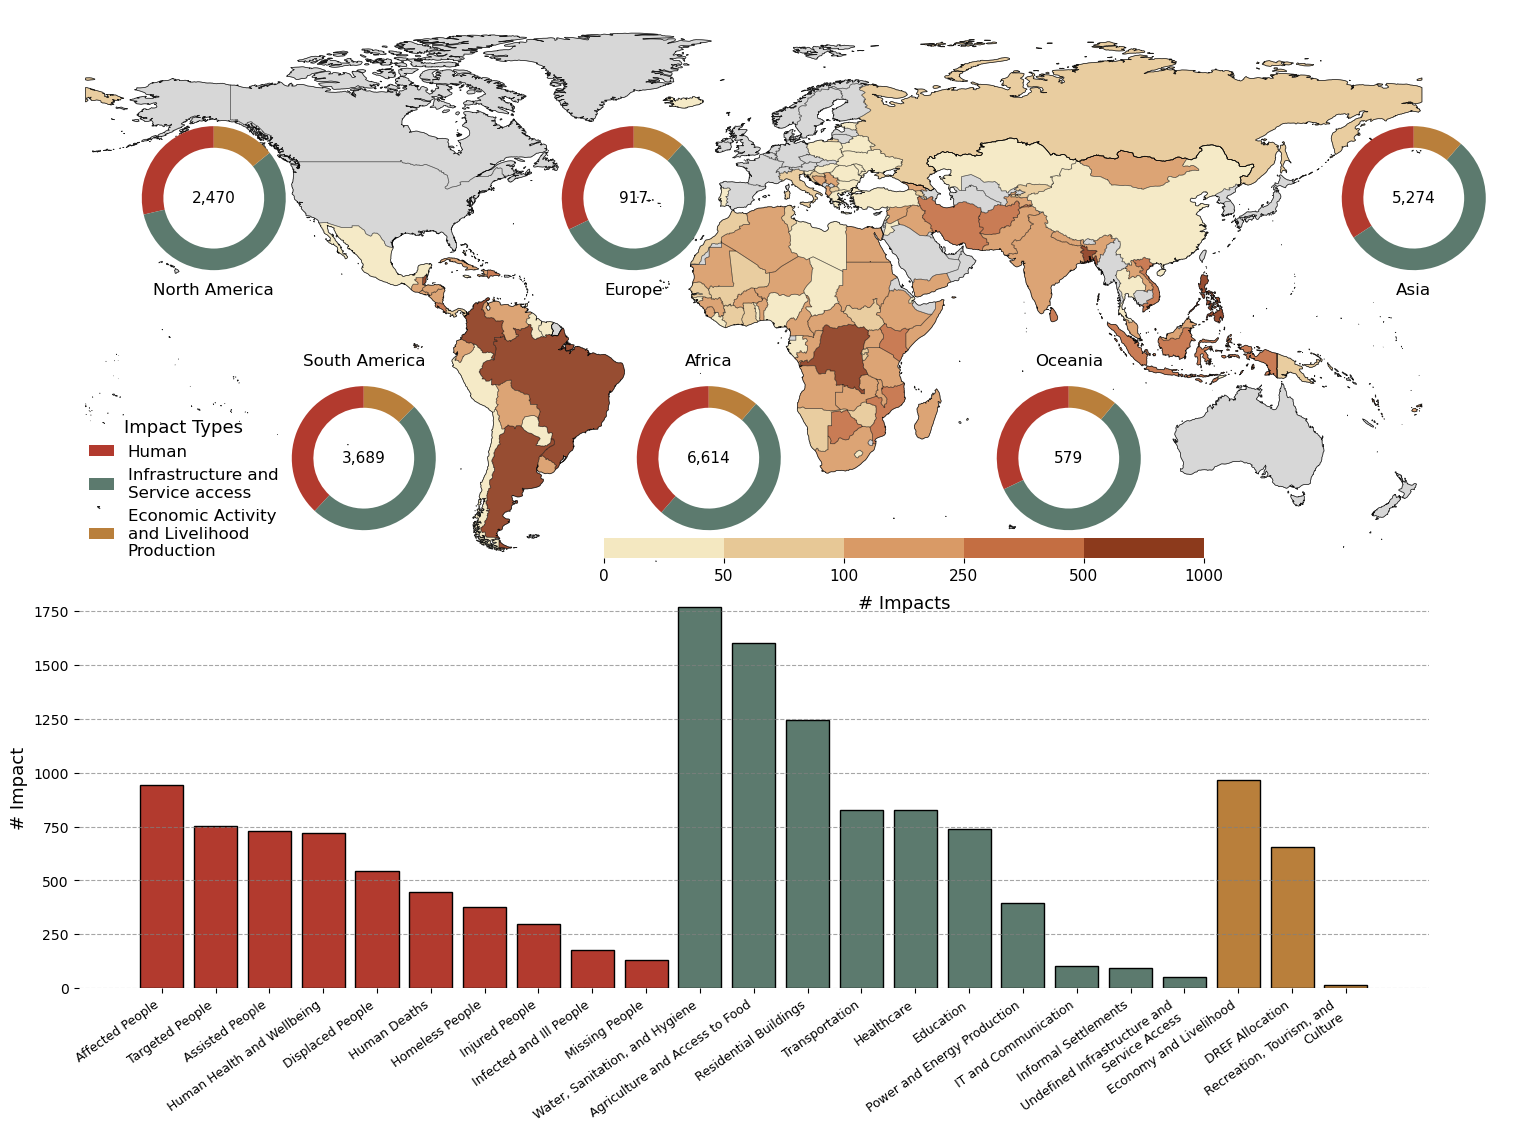

In [ ]:
# Step 3: Plot the static choropleth map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

ax.set_ylim(-60, 90)

# Transparent country boundaries
world.boundary.plot(ax=ax, edgecolor="black", linewidth=0.5, alpha=0.4)

# # Color map for choropleth
# sequential_cmap = LinearSegmentedColormap.from_list(
#     "warm_earth_seq",
#     ["#F4E8C1", "#E7C896", "#D99A66", "#C46E42", "#8C3A1C"],
#     N=256
# )

colors_5 = ["#F4E8C1", "#E7C896", "#D99A66", "#C46E42", "#8C3A1C"]
cmap_5 = ListedColormap(colors_5, name="warm_earth_5")

values = world_impact["impact_count"].dropna()

# 5 classes → 6 boundaries
# bounds = np.quantile(values, [0.02, 0.22, 0.42, 0.62, 0.82, 0.98])
bounds = [0, 50, 100, 250, 500, 1000]

norm = BoundaryNorm(bounds, cmap_5.N)

world_impact.plot(
    column="impact_count",
    ax=ax,
    cmap=cmap_5,
    norm=norm,
    legend=False,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    alpha=0.9
)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap_5, norm=norm)
sm._A = []
cbar_ax = fig.add_axes([0.4, 0.23, 0.4, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
# cbar = fig.colorbar(sm, cax=cbar_ax, orientation="vertical")
cbar.ax.tick_params(labelsize=11)
cbar.outline.set_visible(False)
cbar.set_label("# Impacts", fontsize=13, labelpad=8)

ax.set_axis_off()

# Prepare continent data
all_report_impact_count_clean = all_report_impact_maintype_count.reset_index()
all_report_impact_count_clean['continent'] = all_report_impact_count_clean['iso_code'].apply(
    lambda iso: get_continent(iso, world_impact) if iso else None
)

continent_shapes = world_impact.dissolve(by='CONTINENT')
continent_shapes_proj = continent_shapes.to_crs("ESRI:54030")
continent_centroids_proj = continent_shapes_proj.centroid
continent_centroids = continent_centroids_proj.to_crs(world_impact.crs)

# Add continents boundaries
continent_shapes.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5, alpha=0.8)

continents_plot = ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']

# Calculate impact percentages per continent
continent_impact_counts = (
    all_report_impact_count_clean
    .groupby(['continent', 'impact_main_type'])['impact_count']
    .sum()
    .unstack(fill_value=0)
)

# Order columns and calculate percentages
impact_order = list(impact_colormap.keys())
continent_impact_counts = continent_impact_counts.reindex(columns=impact_order, fill_value=0)
continent_impact_pct = continent_impact_counts.div(continent_impact_counts.sum(axis=1), axis=0) * 100

# Continent position offsets for donut charts
continent_offsets = {
    'Africa': (0.38, 0.24),
    'Asia': (0.85, 0.50),
    'Europe': (0.33, 0.50),
    'North America': (0.05, 0.50),
    'Oceania': (0.62, 0.24),
    'South America': (0.15, 0.24)
}

# Plot donut charts for each continent
for continent in continents_plot:
    if continent not in continent_centroids.index or continent not in continent_impact_pct.index:
        continue

    centroid = continent_centroids.loc[continent]
    if pd.isna(centroid.x) or pd.isna(centroid.y):
        continue

    # Get position offsets
    x_value, y_value = continent_offsets.get(continent, (0, 0))

    # Create axis for donut chart
    ax_donut = fig.add_axes([x_value, y_value, 0.18, 0.18])
    ax_donut.set_facecolor('white')
    ax_donut.patch.set_alpha(0.7)
    
    # Impact data
    impact_data = continent_impact_pct.loc[continent]
    impact_data = impact_data[impact_data > 0]
    impact_labels = impact_data.index
    impact_sizes = impact_data.values
    impact_colors = [impact_colormap.get(label, '#BBBBBB') for label in impact_labels]

    # Impact donut
    # wedges_impact, _ = ax_donut.pie(impact_sizes, colors=['#DDDDDD'] * len(impact_sizes), startangle=90, wedgeprops=dict(width=0.45))
    wedges_impact, _ = ax_donut.pie(impact_sizes, colors=impact_colors, startangle=90, wedgeprops=dict(width=0.3))
    
    # Add the total impact value 
    total_impacts = int(continent_impact_counts.loc[continent].sum())
    ax_donut.text(
        0, 0, f'{total_impacts:,}',  # center text
        ha='center', va='center',
        fontsize=11, color='black'
    )

    #Make the donus
    for i, (size, wedge) in enumerate(zip(impact_sizes, wedges_impact)):
        if size >= 10:
            angle = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
            x = 0.5 * np.cos(np.radians(angle))
            y = 0.5 * np.sin(np.radians(angle))

    # Remove axis frame
    ax_donut.set_frame_on(False)
    ax_donut.set_xticks([])
    ax_donut.set_yticks([])

    if continent in ['North America', 'Asia', 'Europe'] :
        ax_donut.set_title(continent, fontsize=12, pad=2, y=-0.05)
    else : 
        ax_donut.set_title(continent, fontsize=12, pad=2, y=1)

# Add impact legend for impact types
wrapped_labels = {
    impact: '\n'.join(textwrap.wrap(impact, width=20))  # adjust width as needed
    for impact in impact_order if impact in impact_colormap
}

legend_ax = fig.add_axes([0.02, 0.1, 0.2, 0.4])
legend_ax.set_facecolor('white')
legend_ax.patch.set_alpha(0.8)

# Create legend elements with wrapped labels
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, fc=impact_colormap[impact], label=wrapped_labels[impact])
    for impact in impact_order if impact in impact_colormap
]

# Add legend (allowing multiple columns if many elements)
legend_ax.legend(
    handles=legend_elements,
    loc='center',
    frameon=False,
    fontsize=12,
    title='Impact Types',
    title_fontsize=13,
    ncol=1,               # 🔹 split legend into 2 columns if long
    columnspacing=1.5,
    handlelength=1.5
)
legend_ax.set_axis_off()

# Add barplot of impact subtypes 
barplot_subtype_ax = fig.add_axes([0.05, -0.20, 0.9, 0.4])
barplot_subtype_ax.set_facecolor('white')
barplot_subtype_ax.patch.set_alpha(0)

impact_order = list(impact_colormap.keys())

all_reports_impactsubtype['impact_main_type'] = (
    pd.Categorical(
        all_reports_impactsubtype['impact_main_type'],
        categories=impact_order,
        ordered=True
    )
)

# Sort by: category (circle plot order) → subtype count (descending)
all_reports_impactsubtype_sorted = (
    all_reports_impactsubtype
    .sort_values(by=["impact_main_type", "impact_subtype_count"],
                 ascending=[True, False])
    .reset_index(drop=True)
)

barplot_subtype_ax.bar(
    x=all_reports_impactsubtype_sorted['impactSubtype'],
    height=all_reports_impactsubtype_sorted['impact_subtype_count'],
    color=all_reports_impactsubtype_sorted['color'],
    edgecolor='black'
)

# Rotate and add y labels
wrapped_labels = [
    '\n'.join(textwrap.wrap(label, width=30))  # creates multi-line if long
    for label in all_reports_impactsubtype_sorted['impactSubtype']
]
barplot_subtype_ax.set_xticks(range(len(all_reports_impactsubtype_sorted)))
barplot_subtype_ax.set_xticklabels(wrapped_labels, rotation=35, ha='right')

# Optional: improve layout and readability
barplot_subtype_ax.tick_params(axis='x', labelsize=9)
for spine in barplot_subtype_ax.spines.values():
    spine.set_visible(False)
barplot_subtype_ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.7)
barplot_subtype_ax.set_ylabel('# Impact', fontsize=13)

plt.tight_layout()
fig.savefig(path_save_fig / f"impact_map.png", 
            transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"impact_map.svg", 
            format="svg", transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"impact_map.pdf", 
            format="pdf", transparent=True, bbox_inches='tight', dpi=300)

plt.show()